# ML PROJECT 1
# CLASSIFICATION DATASET :  DIABETES DATASET

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV 
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
--- DATA LOAD ---

In [2]:
df=pd.read_csv("C:/Users/YUKESH/Downloads/Diabetes_dataset.csv")
df

,Name,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Dinesh Kumar,Female,80.0,0,1,never,25.19,6.6,140,No
1,Kavin Devi,Female,54.0,0,0,No Info,27.32,6.6,80,No
2,Aarthi Verma,Male,28.0,0,0,never,27.32,5.7,158,No
3,Riya Raj,Female,36.0,0,0,current,23.45,5.0,155,No
4,Rohit Raj,Male,76.0,1,1,current,20.14,4.8,155,No
...,...,...,...,...,...,...,...,...,...,...
9995,Sanjay Das,Female,9.0,0,0,never,25.28,5.8,130,No
9996,Aakash Raj,Male,59.0,0,0,ever,35.00,6.8,140,Yes
9997,Arun Devi,Male,2.0,0,0,never,17.43,4.5,126,No
9998,Harish Kumar,Male,61.0,1,0,ever,31.89,5.7,140,No


In [ ]:
--- DROPED UNWANTED DATA COLUMN ---

In [3]:
df=df.drop("Name",axis=1)
df

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,No
1,Female,54.0,0,0,No Info,27.32,6.6,80,No
2,Male,28.0,0,0,never,27.32,5.7,158,No
3,Female,36.0,0,0,current,23.45,5.0,155,No
4,Male,76.0,1,1,current,20.14,4.8,155,No
...,...,...,...,...,...,...,...,...,...
9995,Female,9.0,0,0,never,25.28,5.8,130,No
9996,Male,59.0,0,0,ever,35.00,6.8,140,Yes
9997,Male,2.0,0,0,never,17.43,4.5,126,No
9998,Male,61.0,1,0,ever,31.89,5.7,140,No


In [ ]:
--- ENCODING ---

In [4]:
hh=LabelEncoder()
df["gender"]=hh.fit_transform(df["gender"])
df["smoking_history"]=hh.fit_transform(df["smoking_history"])
df["diabetes"]=hh.fit_transform(df["diabetes"])
df

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,0,80.0,0,1,4,25.19,6.6,140,0
1,0,54.0,0,0,0,27.32,6.6,80,0
2,1,28.0,0,0,4,27.32,5.7,158,0
3,0,36.0,0,0,1,23.45,5.0,155,0
4,1,76.0,1,1,1,20.14,4.8,155,0
...,...,...,...,...,...,...,...,...,...
9995,0,9.0,0,0,4,25.28,5.8,130,0
9996,1,59.0,0,0,2,35.00,6.8,140,1
9997,1,2.0,0,0,4,17.43,4.5,126,0
9998,1,61.0,1,0,2,31.89,5.7,140,0


In [5]:
df.describe()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,0.421000,41.991556,0.075300,0.037400,2.185100,27.331413,5.520650,137.852100,0.08590
std,0.493744,22.540364,0.263888,0.189749,1.882709,6.650023,1.082118,41.228493,0.28023
min,0.000000,0.080000,0.000000,0.000000,0.000000,10.010000,3.500000,80.000000,0.00000
25%,0.000000,24.000000,0.000000,0.000000,0.000000,23.710000,4.800000,100.000000,0.00000
50%,0.000000,43.000000,0.000000,0.000000,3.000000,27.320000,5.800000,140.000000,0.00000
75%,1.000000,59.000000,0.000000,0.000000,4.000000,29.600000,6.200000,159.000000,0.00000
max,1.000000,80.000000,1.000000,1.000000,5.000000,88.720000,9.000000,300.000000,1.00000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   gender               10000 non-null  int64  
 1   age                  10000 non-null  float64
 2   hypertension         10000 non-null  int64  
 3   heart_disease        10000 non-null  int64  
 4   smoking_history      10000 non-null  int64  
 5   bmi                  10000 non-null  float64
 6   HbA1c_level          10000 non-null  float64
 7   blood_glucose_level  10000 non-null  int64  
 8   diabetes             10000 non-null  int64  
dtypes: float64(3), int64(6)
memory usage: 703.3 KB


In [ ]:
--- HANDLING NULL VALUES --- 

In [7]:
df.isnull().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

In [ ]:
--- IN THIS DATASET, NO MISSING VALUE ARE PRESENT ---

In [ ]:
--- HANDLING OUTLIERS ---

In [8]:
def replace_outliers(dataframe,feature):
    q1=dataframe[feature].quantile(0.25)
    q3=dataframe[feature].quantile(0.75)
    iqr=q3-q1
    lower_range=q1-1.5*iqr
    upper_range=q3+1.5*iqr
    dataframe[feature]=np.where(dataframe[feature]<lower_range,lower_range,dataframe[feature])
    dataframe[feature]=np.where(dataframe[feature]>upper_range,upper_range,dataframe[feature])

<Axes: xlabel='gender'>

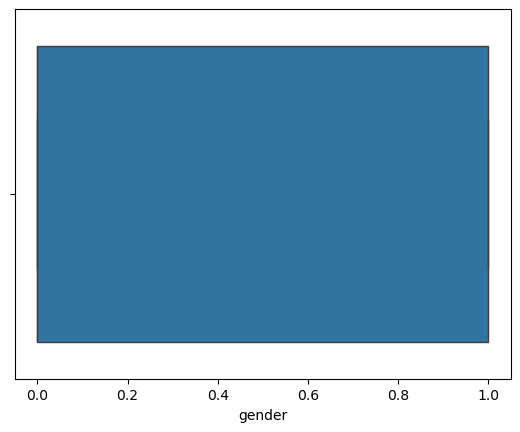

In [9]:
sns.boxplot(x="gender",data=df)

<Axes: xlabel='age'>

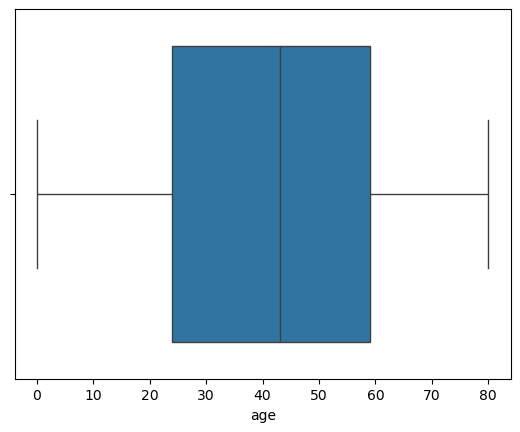

In [10]:
sns.boxplot(x="age",data=df)

<Axes: xlabel='hypertension'>

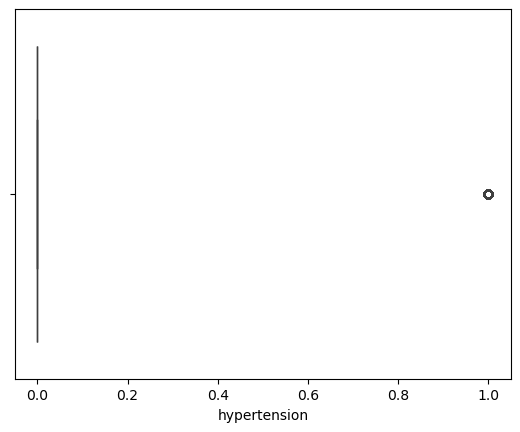

In [11]:
sns.boxplot(x="hypertension",data=df)

<Axes: xlabel='heart_disease'>

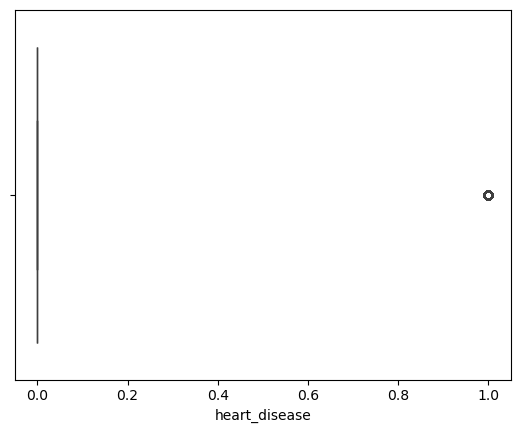

In [12]:
sns.boxplot(x="heart_disease",data=df)

<Axes: xlabel='smoking_history'>

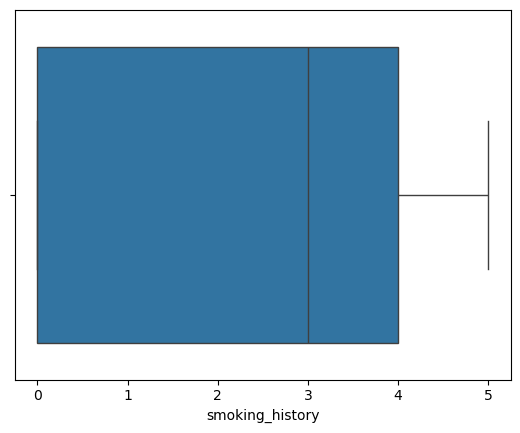

In [13]:
sns.boxplot(x="smoking_history",data=df)

<Axes: xlabel='bmi'>

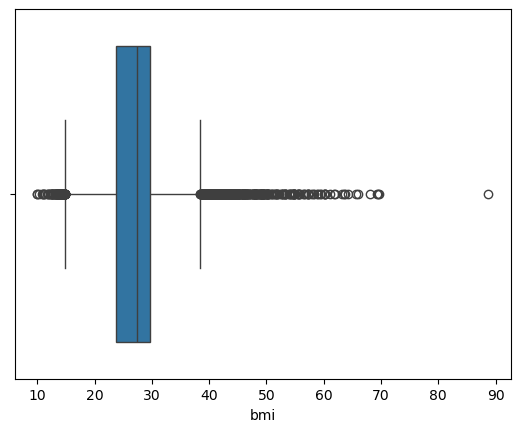

In [14]:
sns.boxplot(x="bmi",data=df)

<Axes: xlabel='HbA1c_level'>

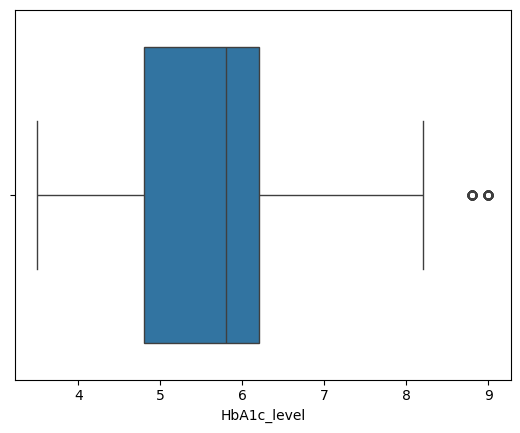

In [15]:
sns.boxplot(x="HbA1c_level",data=df)

<Axes: xlabel='blood_glucose_level'>

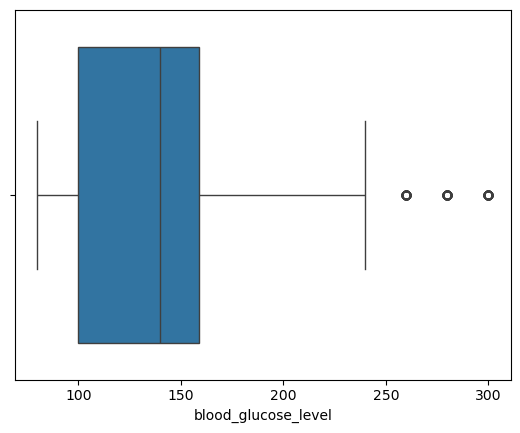

In [16]:
sns.boxplot(x="blood_glucose_level",data=df)

<Axes: xlabel='diabetes'>

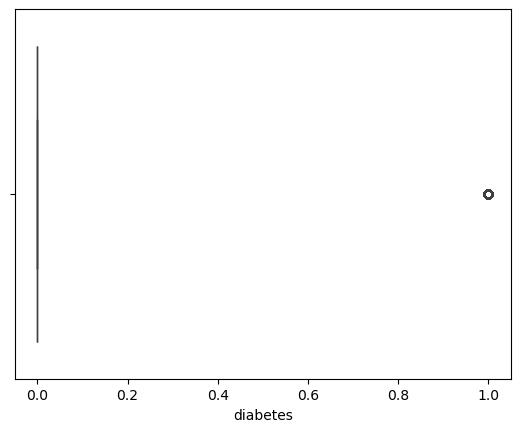

In [17]:
sns.boxplot(x="diabetes",data=df)

<Axes: xlabel='bmi'>

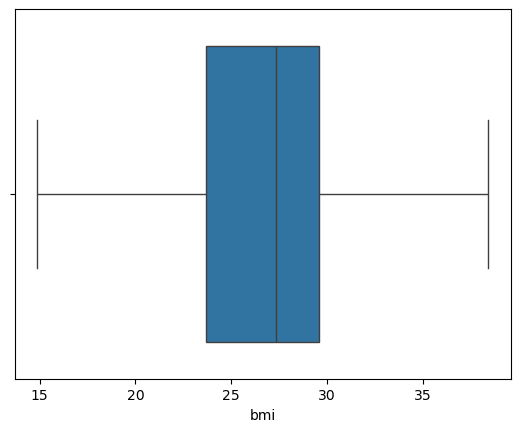

In [18]:
replace_outliers(df,'bmi')
sns.boxplot(x='bmi',data=df)

<Axes: xlabel='HbA1c_level'>

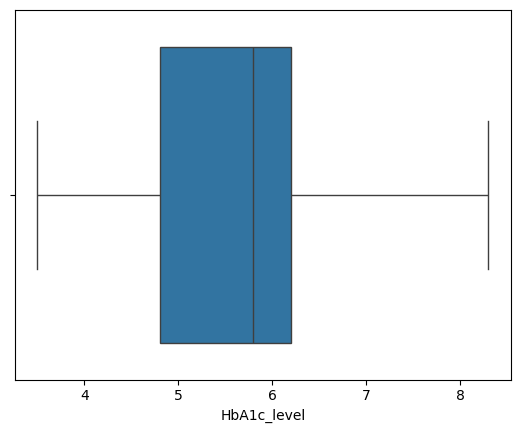

In [19]:
replace_outliers(df,'HbA1c_level')
sns.boxplot(x='HbA1c_level',data=df)

<Axes: xlabel='blood_glucose_level'>

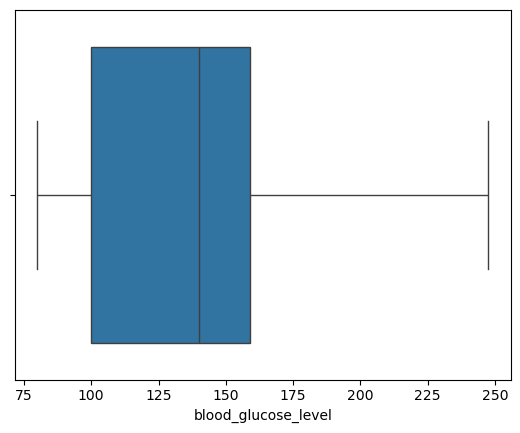

In [20]:
replace_outliers(df,'blood_glucose_level')
sns.boxplot(x='blood_glucose_level',data=df)

In [ ]:
--- SPLITING Y AND X ---

In [21]:
y=df["diabetes"]
y

0       0
1       0
2       0
3       0
4       0
       ..
9995    0
9996    1
9997    0
9998    0
9999    0
Name: diabetes, Length: 10000, dtype: int64

In [22]:
x=df.drop("diabetes",axis=1)
x

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level
0,0,80.0,0,1,4,25.19,6.6,140.0
1,0,54.0,0,0,0,27.32,6.6,80.0
2,1,28.0,0,0,4,27.32,5.7,158.0
3,0,36.0,0,0,1,23.45,5.0,155.0
4,1,76.0,1,1,1,20.14,4.8,155.0
...,...,...,...,...,...,...,...,...
9995,0,9.0,0,0,4,25.28,5.8,130.0
9996,1,59.0,0,0,2,35.00,6.8,140.0
9997,1,2.0,0,0,4,17.43,4.5,126.0
9998,1,61.0,1,0,2,31.89,5.7,140.0


In [ ]:
--- TRAINING PROCESS ---

In [23]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
--- HADALING IMBALANCE DATA ---

In [24]:
y_train.value_counts()

diabetes
0    7307
1     693
Name: count, dtype: int64

In [25]:
smote = SMOTE(sampling_strategy='minority')
x_sm, y_sm = smote.fit_resample(x_train, y_train)
y_sm.value_counts()

diabetes
0    7307
1    7307
Name: count, dtype: int64

In [ ]:
--- MODEL 1 ---
--- DECISION TREE CLASSIFIER ---

In [26]:
model1=DecisionTreeClassifier()
model1.fit(x_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [27]:
# test_accurarcy
y_pred1=model1.predict(x_test)
accuracy1=accuracy_score(y_test,y_pred1)
accuracy1

0.9505

In [28]:
# training _accuracy 
y_train_pred1=model1.predict(x_train)
final_training1=accuracy_score(y_train_pred1,y_train)
final_training1

1.0

In [29]:
# Hyperparameter
model_1=DecisionTreeClassifier()
param_grid = {
    'max_depth': [3, 5, 10],
    'min_samples_split': [2,5,6,7,3,10],
    'min_samples_leaf': [1, 2,3,4]
}

# GridSearchCV
grid_search = GridSearchCV(estimator=model_1, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# Train
grid_search.fit(x_train, y_train)

# Best parameters
print("Best Parameters:", grid_search.best_params_)

# Best model
best_model = grid_search.best_estimator_

# Test accuracy
y_pred = best_model.predict(x_test)
print("Accuracy:", accuracy_score(y_test,y_pred))

Best Parameters: {'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
Accuracy: 0.972


In [30]:
# The best parameter for decision tree 
model_1=DecisionTreeClassifier(max_depth= 3, min_samples_leaf= 1, min_samples_split= 2)

In [31]:
# test_accurarcy
model_1.fit(x_train,y_train)
y_pred_1=model_1.predict(x_test)
accuracy_1=accuracy_score(y_test,y_pred_1)
accuracy_1

0.972

In [32]:
# training _accuracy 
y_train_pred_1=model_1.predict(x_train)
final_training_1=accuracy_score(y_train_pred_1,y_train)
final_training_1

0.972375

In [33]:
# classification_report
cr1 = classification_report(y_test, y_pred, target_names=["No diabetes no as 0", "diabetes yes as 1"])
print("\nDecision tree:")
print("\nClassification Report:")
print(cr1)


Decision tree:

Classification Report:
                     precision    recall  f1-score   support

No diabetes no as 0       0.97      1.00      0.98      1834
  diabetes yes as 1       1.00      0.66      0.80       166

           accuracy                           0.97      2000
          macro avg       0.99      0.83      0.89      2000
       weighted avg       0.97      0.97      0.97      2000



In [ ]:
--- MODEL 2 ---
--- RANDOM FOREST CLASSIFIER ---

In [34]:
model2=RandomForestClassifier()
model2.fit(x_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [35]:
# test_accurarcy
y_pred2=model2.predict(x_test)
accuracy2=accuracy_score(y_test,y_pred2)
accuracy2

0.9705

In [36]:
# training _accuracy 
y_train_pred2=model2.predict(x_train)
final_training2=accuracy_score(y_train,y_train_pred2)
final_training2

0.999875

In [37]:
#Hyper paameter
model_2=RandomForestClassifier()
parameter = {
    'n_estimators': [100,177],
    'max_features': [5,9],
    'max_depth': [3, 5, 10],
    'min_samples_split': [2,5,6,7,3,10],
    'min_samples_leaf': [1, 2,3,4]
}

# GridSearchCV
random = RandomizedSearchCV(estimator=model_2, param_distributions=parameter, cv=5, scoring='accuracy', n_jobs=-1)

# Train
random.fit(x_train, y_train)

# Best parameters
print("Best Parameters:", random.best_params_)

# Best model
best_model = random.best_estimator_

# Test accuracy
y_pred = best_model.predict(x_test)
print("Accuracy:", accuracy_score(y_test,y_pred))

Best Parameters: {'n_estimators': 177, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 5, 'max_depth': 3}
Accuracy: 0.972


In [38]:
model_2=RandomForestClassifier(max_depth= 5,max_features= 9,min_samples_leaf= 3, min_samples_split= 3,n_estimators= 100)

In [39]:
model_2.fit(x_train,y_train)
y_pred_2=model_2.predict(x_test)
accuracy_2=accuracy_score(y_test,y_pred_2)
accuracy_2

0.972

In [40]:
# training _accuracy 
y_train_pred_2=model_2.predict(x_train)
final_training_2=accuracy_score(y_train_pred_2,y_train)
final_training_2

0.972375

In [41]:
# classification_report
cr2 = classification_report(y_test, y_pred, target_names=["No diabetes no as 0", "diabetes yes as 1"])
print("\nRandom forest:")
print("\nClassification Report:")
print(cr2)


Random forest:

Classification Report:
                     precision    recall  f1-score   support

No diabetes no as 0       0.97      1.00      0.98      1834
  diabetes yes as 1       1.00      0.66      0.80       166

           accuracy                           0.97      2000
          macro avg       0.99      0.83      0.89      2000
       weighted avg       0.97      0.97      0.97      2000



In [ ]:
--- SCALING ---

In [42]:
scale=StandardScaler()
x_train_scaled=scale.fit_transform(x_train)
x_test_scaled=scale.transform(x_test)

In [ ]:
--- MODEL 3 ---
--- LOGISTIC REGRESSION ---

In [43]:
model3=LogisticRegression()
model3.fit(x_train_scaled,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [44]:
# test_accurarcy
y_pred3=model3.predict(x_test_scaled)
accuracy3=accuracy_score(y_test,y_pred3)
accuracy3

0.963

In [45]:
# training _accuracy 
y_train_pred3=model3.predict(x_train_scaled)
final_training3=accuracy_score(y_train,y_train_pred3)
final_training3

0.959625

In [46]:
# classification_report
cr3 = classification_report(y_test, y_pred, target_names=["No diabetes no as 0", "diabetes yes as 1"])
print("\nLogistic Regression:")
print("\nClassification Report:")
print(cr3)


Logistic Regression:

Classification Report:
                     precision    recall  f1-score   support

No diabetes no as 0       0.97      1.00      0.98      1834
  diabetes yes as 1       1.00      0.66      0.80       166

           accuracy                           0.97      2000
          macro avg       0.99      0.83      0.89      2000
       weighted avg       0.97      0.97      0.97      2000



In [ ]:
--- MODEL 4 ---
--- KNN [K NEAREST NEIGHBORS CLASSIFIER] ---

In [47]:
model4=KNeighborsClassifier()
model4.fit(x_train_scaled,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [48]:
# testing_accuracy
y_pred4=model4.predict(x_test_scaled)
accuracy4=accuracy_score(y_test,y_pred4)
accuracy4

0.9635

In [49]:
# training _accuracy 
y_train_pred4=model4.predict(x_train_scaled)
final_training4=accuracy_score(y_train_pred4,y_train)
final_training4

0.965875

In [50]:
# hyper parameter
model_3=KNeighborsClassifier()

parameter = {'n_neighbors': [3,5,7], 'metric': ['euclidean', 'manhattan'] }

grid = GridSearchCV( estimator=model_3, param_grid=parameter, cv=5, scoring='accuracy' )

grid.fit(x_train_scaled,y_train)

print("Best parameters:", grid.best_params_)

print("Best CV score:", grid.best_score_)

Best parameters: {'metric': 'manhattan', 'n_neighbors': 7}
Best CV score: 0.959125


In [51]:
# Applying best parameter
model_3=KNeighborsClassifier(metric='manhattan',n_neighbors=7)

In [52]:
# testing_accuracy (after applying best parameter)
model_3.fit(x_train_scaled,y_train)
y_pred_3=model_3.predict(x_test_scaled)
accuracy_3=accuracy_score(y_test,y_pred_3)
accuracy_3

0.962

In [53]:
# training _accuracy 
y_train_pred_3=model_3.predict(x_train_scaled)
final_training_3=accuracy_score(y_train,y_train_pred_3)
final_training_3

0.96525

In [54]:
# clssification_report
cr4 = classification_report(y_test, y_pred, target_names=["No diabetes no as 0", "diabetes yes as 1"])
print("\nK Nearest Neighbors:")
print("\nClassification Report:")
print(cr4)


K Nearest Neighbors:

Classification Report:
                     precision    recall  f1-score   support

No diabetes no as 0       0.97      1.00      0.98      1834
  diabetes yes as 1       1.00      0.66      0.80       166

           accuracy                           0.97      2000
          macro avg       0.99      0.83      0.89      2000
       weighted avg       0.97      0.97      0.97      2000



In [ ]:
--- MODEL 5 ---
--- NAIVE BAYES ---

In [55]:
model5=GaussianNB()
model5.fit(x_train_scaled,y_train)

,priors,None
,var_smoothing,1e-09


In [56]:
# testing_accuracy
y_pred5=model5.predict(x_test_scaled)
accuracy5=accuracy_score(y_test,y_pred5)
accuracy5

0.905

In [57]:
# training _accuracy 
y_train_pred5=model5.predict(x_train_scaled)
final_training5=accuracy_score(y_train,y_train_pred5)
final_training5

0.90725

In [58]:
# classification_report
cr5 = classification_report(y_test, y_pred, target_names=["No diabetes no as 0", "diabetes yes as 1"])
print("\nNaive bayes")
print("\nClassification Report:")
print(cr5)


Naive bayes

Classification Report:
                     precision    recall  f1-score   support

No diabetes no as 0       0.97      1.00      0.98      1834
  diabetes yes as 1       1.00      0.66      0.80       166

           accuracy                           0.97      2000
          macro avg       0.99      0.83      0.89      2000
       weighted avg       0.97      0.97      0.97      2000



In [ ]:
--- MODEL 6 ---
--- SVM [SUPPORT VECTOR MACHINE CLASSIFIER] ---

In [59]:
model6=SVC()
model6.fit(x_train_scaled,y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [60]:
# testing_accuracy
y_pred6=model6.predict(x_test_scaled)
accuracy6=accuracy_score(y_test,y_pred6)
accuracy6

0.965

In [61]:
# training _accuracy 
y_train_pred6=model6.predict(x_train_scaled)
final_training6=accuracy_score(y_train,y_train_pred6)
final_training6

0.966375

In [62]:
# Define the model
model_4 = SVC()

# Define parameter grid
parameter = {'C': [0.1, 1, 7,0.4], 'kernel': ['linear', 'rbf'] }

# Grid Search
ran = RandomizedSearchCV( estimator=model_4, param_distributions=parameter, cv=5, scoring='accuracy' )

# Fit using your own training data
ran.fit(x_train_scaled, y_train)

# Best parameters
print("Best parameters:", ran.best_params_)

# Best CV score
print("Best CV score:", ran.best_score_)

C:\Users\YUKESH\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 8 is smaller than n_iter=10. Running 8 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best parameters: {'kernel': 'rbf', 'C': 0.4}
Best CV score: 0.9633749999999999


In [63]:
model_4=SVC(kernel='linear', C= 0.1)
model_4.fit(x_train_scaled,y_train)
y_pred_4=model_4.predict(x_test_scaled)
accuracy_4=accuracy_score(y_test,y_pred_4)
accuracy_4

0.9625

In [64]:
# training _accuracy 
y_train_pred_4=model_4.predict(x_train_scaled)
final_training_4=accuracy_score(y_train,y_train_pred_4)
final_training_4

0.96025

In [65]:
# classification_report
cr6 = classification_report(y_test, y_pred, target_names=["No diabetes no as 0", "diabetes yes as 1"])
print("\nSupport vector machine:")
print("\nClassification Report:")
print(cr6)


Support vector machine:

Classification Report:
                     precision    recall  f1-score   support

No diabetes no as 0       0.97      1.00      0.98      1834
  diabetes yes as 1       1.00      0.66      0.80       166

           accuracy                           0.97      2000
          macro avg       0.99      0.83      0.89      2000
       weighted avg       0.97      0.97      0.97      2000

